# Basic Overview

In [2]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
FILE_PATH = os.path.join(os.getcwd(), 'Dataset','final_internship_data.csv')
df = pd.read_csv(FILE_PATH)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   User ID            500000 non-null  object 
 1   User Name          500000 non-null  object 
 2   Driver Name        500000 non-null  object 
 3   Car Condition      500000 non-null  object 
 4   Weather            500000 non-null  object 
 5   Traffic Condition  500000 non-null  object 
 6   key                500000 non-null  object 
 7   fare_amount        500000 non-null  float64
 8   pickup_datetime    500000 non-null  object 
 9   pickup_longitude   500000 non-null  float64
 10  pickup_latitude    500000 non-null  float64
 11  dropoff_longitude  499995 non-null  float64
 12  dropoff_latitude   499995 non-null  float64
 13  passenger_count    500000 non-null  int64  
 14  hour               500000 non-null  int64  
 15  day                500000 non-null  int64  
 16  mo

In [5]:
df.head()

,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,KHVrEVlD,Kimberly Adams,Amy Butler,Very Good,windy,Congested Traffic,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21,-1.288826,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,lPxIuEri,Justin Tapia,Hannah Zimmerman,Excellent,cloudy,Flow Traffic,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16,-1.291824,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,gsVN8JLS,Elizabeth Lopez,Amanda Jackson,Bad,stormy,Congested Traffic,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00,-1.291242,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,9I7kWFgd,Steven Wilson,Amy Horn,Very Good,stormy,Flow Traffic,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42,-1.291319,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,8QN5ZaGN,Alexander Andrews,Cassandra Larson,Bad,stormy,Congested Traffic,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00,-1.290987,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


In [6]:
df.columns

Index(['User ID', 'User Name', 'Driver Name', 'Car Condition', 'Weather',
       'Traffic Condition', 'key', 'fare_amount', 'pickup_datetime',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count', 'hour', 'day', 'month',
       'weekday', 'year', 'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist',
       'nyc_dist', 'distance', 'bearing'],
      dtype='object')

In [7]:
# ── 2. BASIC OVERVIEW ────────────────────────────────────────────────────────
print("\n--- Descriptive statistics (numeric) ---")
print(df.describe().T.to_string())

print("\n--- Descriptive statistics (object) ---")
print(df.describe(include="object").T.to_string())


--- Descriptive statistics (numeric) ---
                      count         mean          std          min          25%          50%          75%           max
fare_amount        500000.0    11.358361     9.916617   -44.900000     6.000000     8.500000    12.500000    500.000000
pickup_longitude   500000.0    -1.265712     0.206941   -52.119764    -1.291405    -1.291226    -1.290970     37.360538
pickup_latitude    500000.0     0.696740     0.140909   -54.389440     0.710958     0.711268     0.711520     29.724576
dropoff_longitude  499995.0    -1.265755     0.205903   -59.049665    -1.291393    -1.291197    -1.290908      0.712985
dropoff_latitude   499995.0     0.696675     0.128997   -44.676047     0.710943     0.711277     0.711538      7.061893
passenger_count    500000.0     1.683428     1.307395     0.000000     1.000000     1.000000     2.000000      6.000000
hour               500000.0    13.510834     6.511571     0.000000     9.000000    14.000000    19.000000     23.00000

In [8]:
df.isna().sum()

User ID              0
User Name            0
Driver Name          0
Car Condition        0
Weather              0
Traffic Condition    0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    5
dropoff_latitude     5
passenger_count      0
hour                 0
day                  0
month                0
weekday              0
year                 0
jfk_dist             5
ewr_dist             5
lga_dist             5
sol_dist             5
nyc_dist             5
distance             5
bearing              5
dtype: int64

In [9]:
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')

In [10]:
df[['pickup_datetime', 'weekday']].head()

,pickup_datetime,weekday
0,2009-06-15 17:26:21,0
1,2010-01-05 16:52:16,1
2,2011-08-18 00:35:00,3
3,2012-04-21 04:30:42,5
4,2010-03-09 07:51:00,1


In [11]:
df.dropna(inplace=True)

In [12]:
df.drop(columns=['user_id', 'key', 'pickup_datetime'], axis=1, inplace=True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 499995 entries, 0 to 499999
Data columns (total 23 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   user_name          499995 non-null  object 
 1   driver_name        499995 non-null  object 
 2   car_condition      499995 non-null  object 
 3   weather            499995 non-null  object 
 4   traffic_condition  499995 non-null  object 
 5   fare_amount        499995 non-null  float64
 6   pickup_longitude   499995 non-null  float64
 7   pickup_latitude    499995 non-null  float64
 8   dropoff_longitude  499995 non-null  float64
 9   dropoff_latitude   499995 non-null  float64
 10  passenger_count    499995 non-null  int64  
 11  hour               499995 non-null  int64  
 12  day                499995 non-null  int64  
 13  month              499995 non-null  int64  
 14  weekday            499995 non-null  int64  
 15  year               499995 non-null  int64  
 16  jfk_dis

In [14]:
df[['fare_amount', 'distance']].describe()

,fare_amount,distance
count,499995.000000,499995.000000
mean,11.358182,19.468775
std,9.916069,367.299601
min,-44.900000,0.000000
25%,6.000000,1.214550
50%,8.500000,2.116970
75%,12.500000,3.890070
max,500.000000,12399.956433


# visualization


Negative fares : 21
Zero fares     : 14
Fare > $200    : 26
Fare between $0 and $200    : 499934


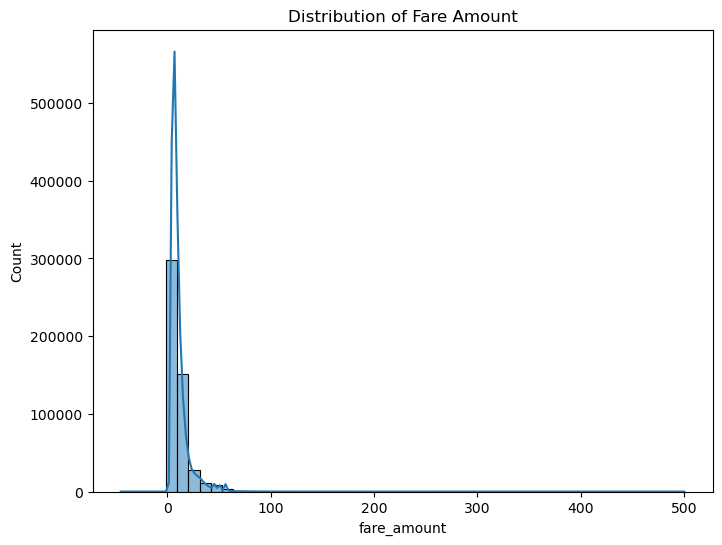

In [15]:
print(f"\nNegative fares : {(df['fare_amount'] < 0).sum()}")
print(f"Zero fares     : {(df['fare_amount'] == 0).sum()}")
print(f"Fare > $200    : {(df['fare_amount'] > 200).sum()}")
print(f"Fare between $0 and $200    : {((df['fare_amount'] > 0) & (df['fare_amount'] <= 200)).sum()}")

plt.figure(figsize=(8,6))
sns.histplot(df['fare_amount'], bins=50, kde=True)
plt.title('Distribution of Fare Amount')
plt.show()

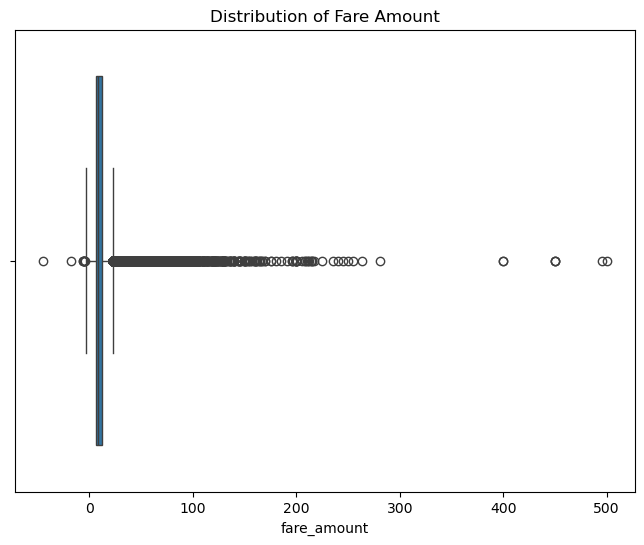

In [16]:
plt.figure(figsize=(8,6))
sns.boxplot(x=df['fare_amount'])
plt.title('Distribution of Fare Amount')
plt.show()

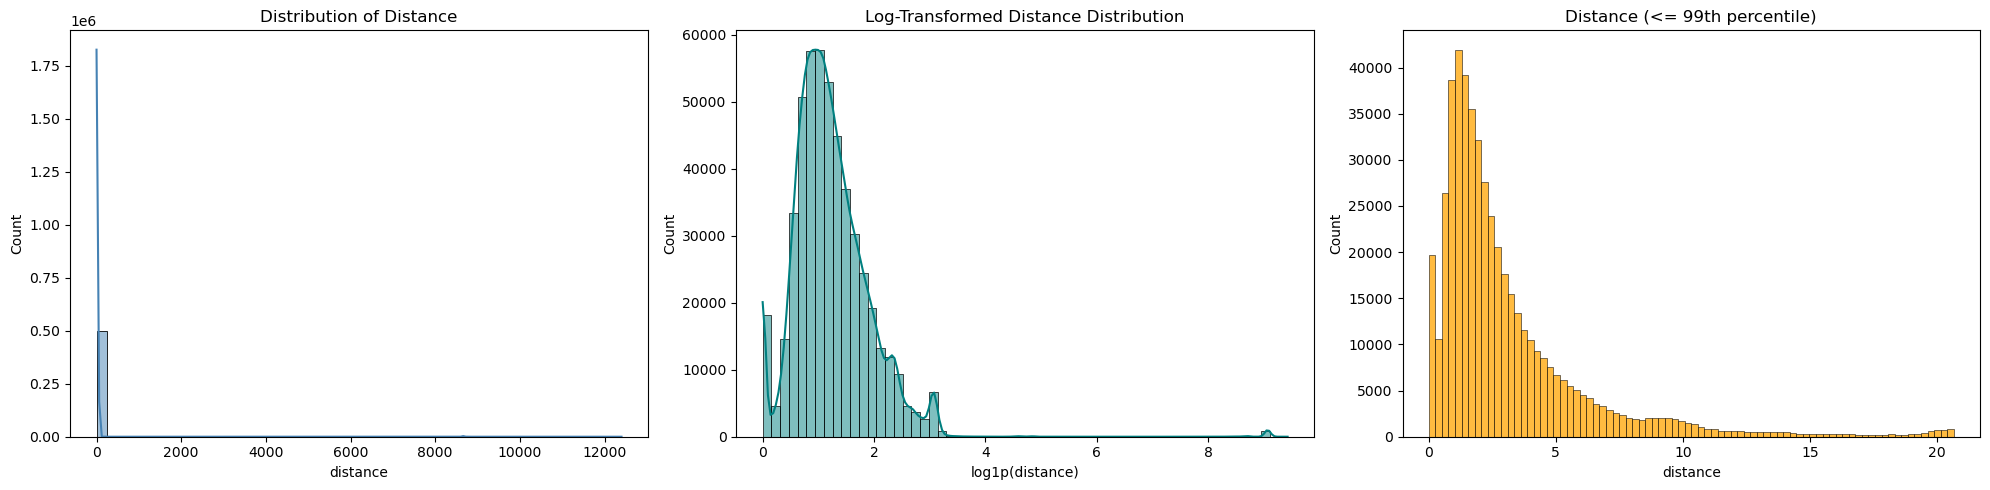

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1) Raw distance
sns.histplot(df['distance'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Distance')
axes[0].set_xlabel('distance')

# 2) Log-transformed distance
sns.histplot(np.log1p(df['distance']), bins=60, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Log-Transformed Distance Distribution')
axes[1].set_xlabel('log1p(distance)')

# 3) Distance <= 99th percentile
p99 = df['distance'].quantile(0.99)
sns.histplot(df.loc[df['distance'] <= p99, 'distance'], bins=80, ax=axes[2], color='orange')
axes[2].set_title('Distance (<= 99th percentile)')
axes[2].set_xlabel('distance')

plt.tight_layout()
plt.show()

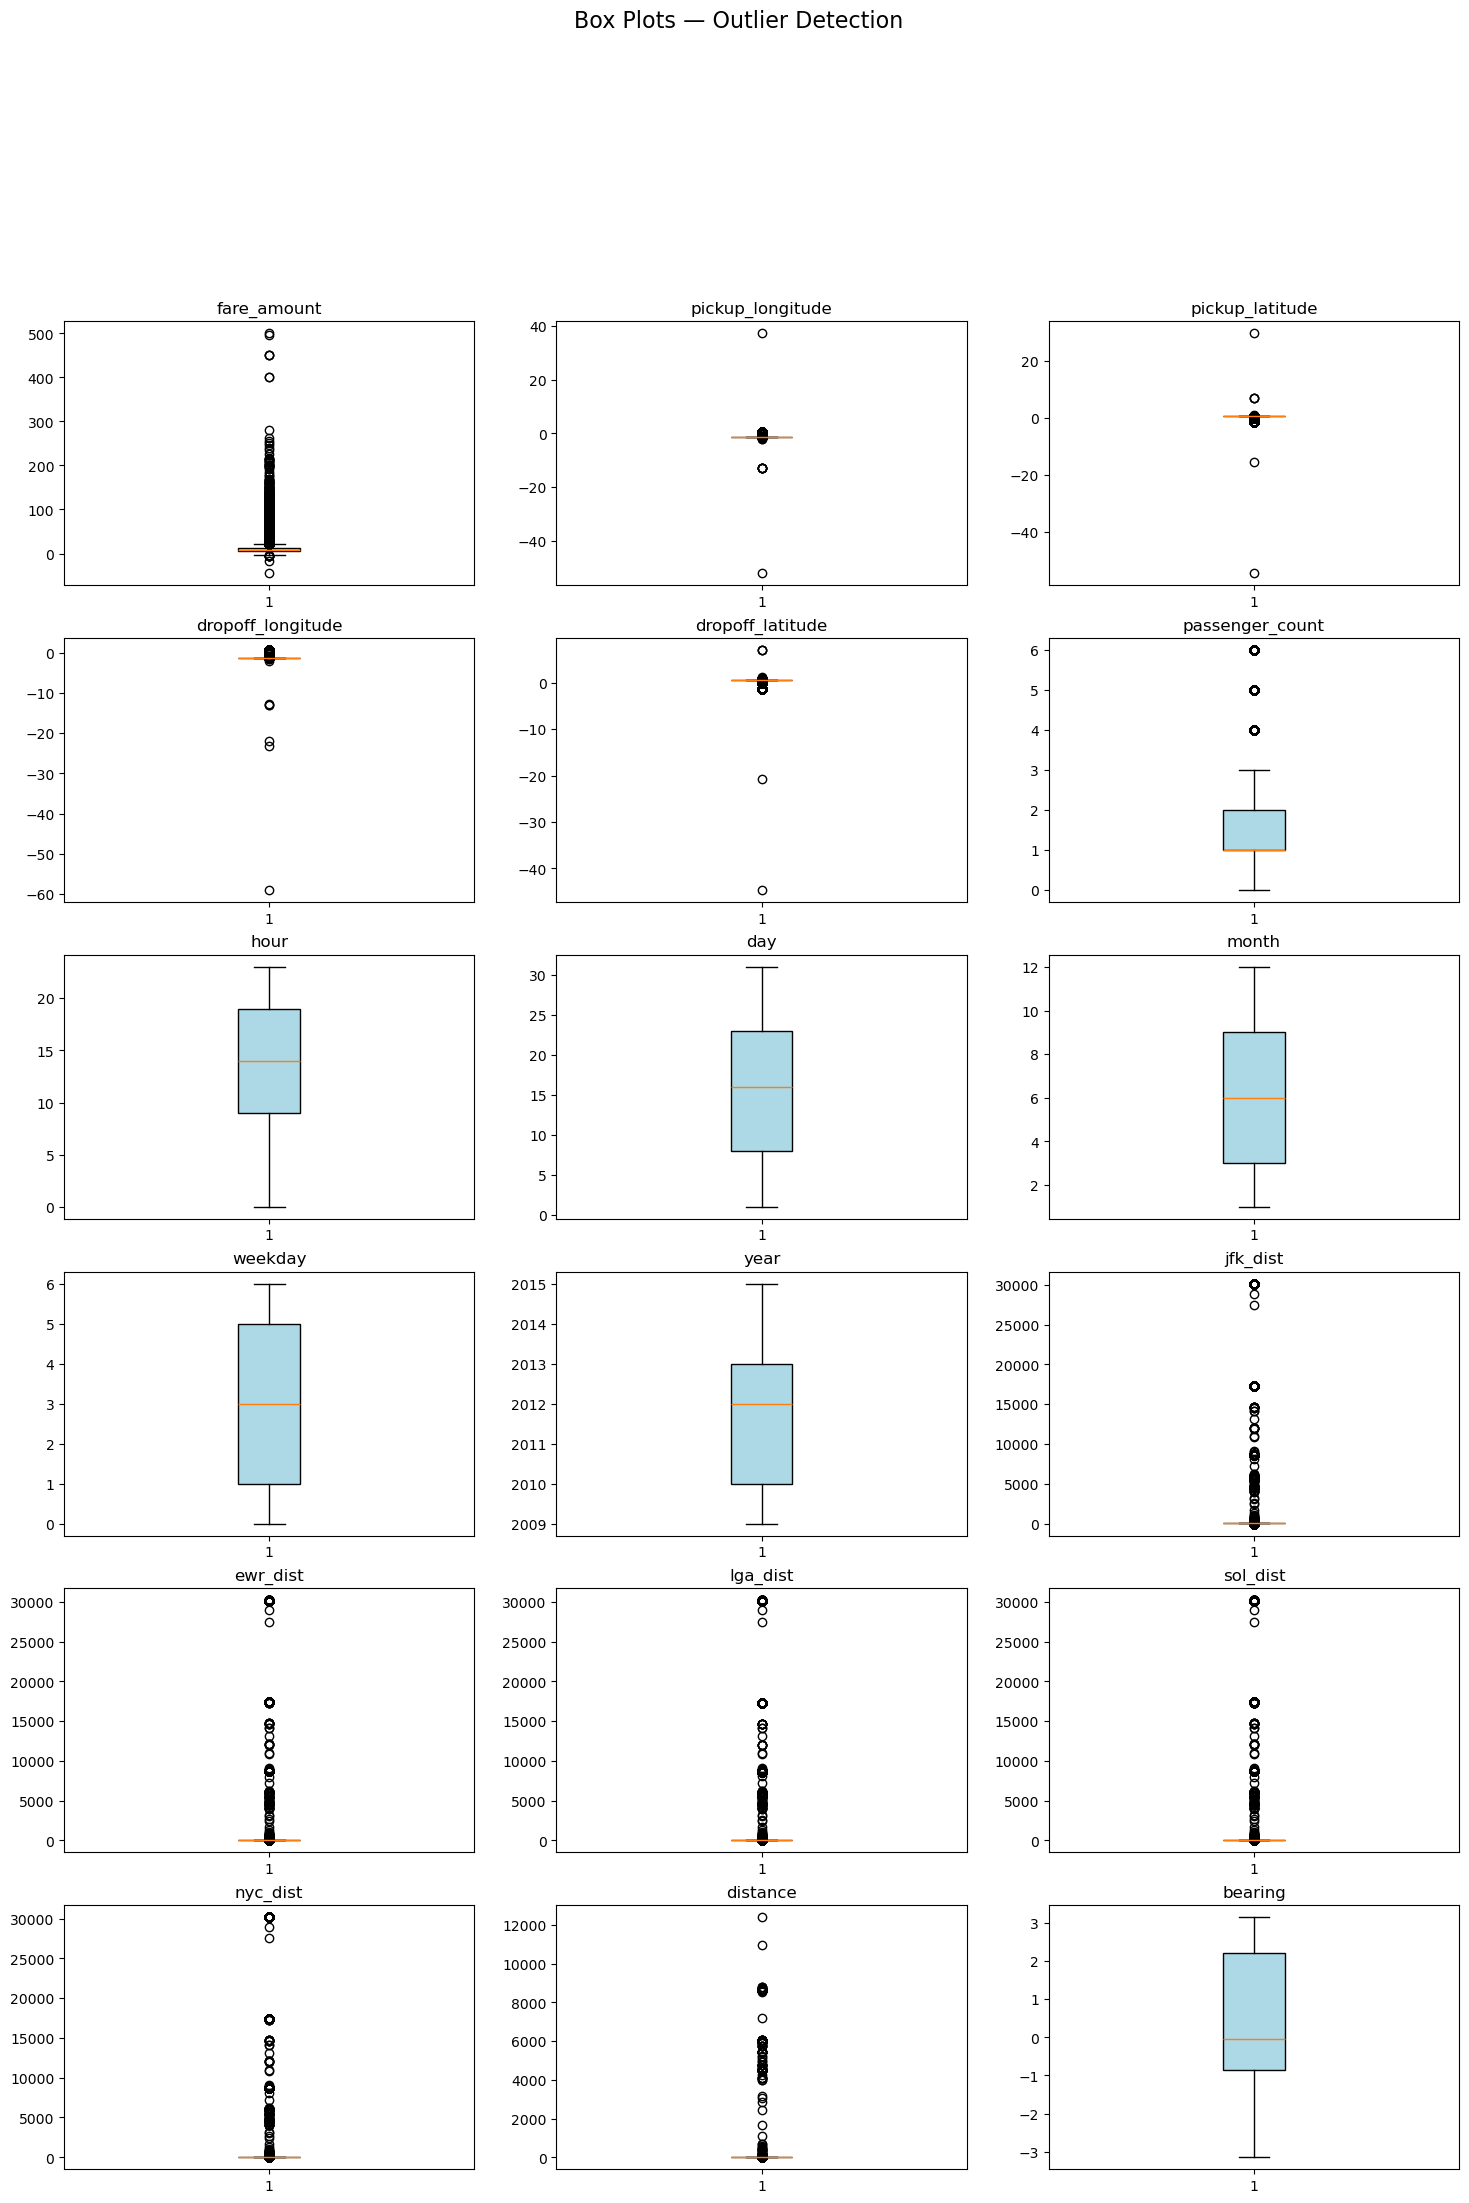

In [18]:
num_cols = df.select_dtypes(include='number')
num_cols = [c for c in num_cols if c in df.columns]

# --- Histograms --- #
n = len(num_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

# --- Box plots for outlier detection ---
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor="lightblue"))
    axes[i].set_title(col)
    axes[i].set_xlabel("")
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Box Plots — Outlier Detection", fontsize=16, y=1.01)
plt.show()

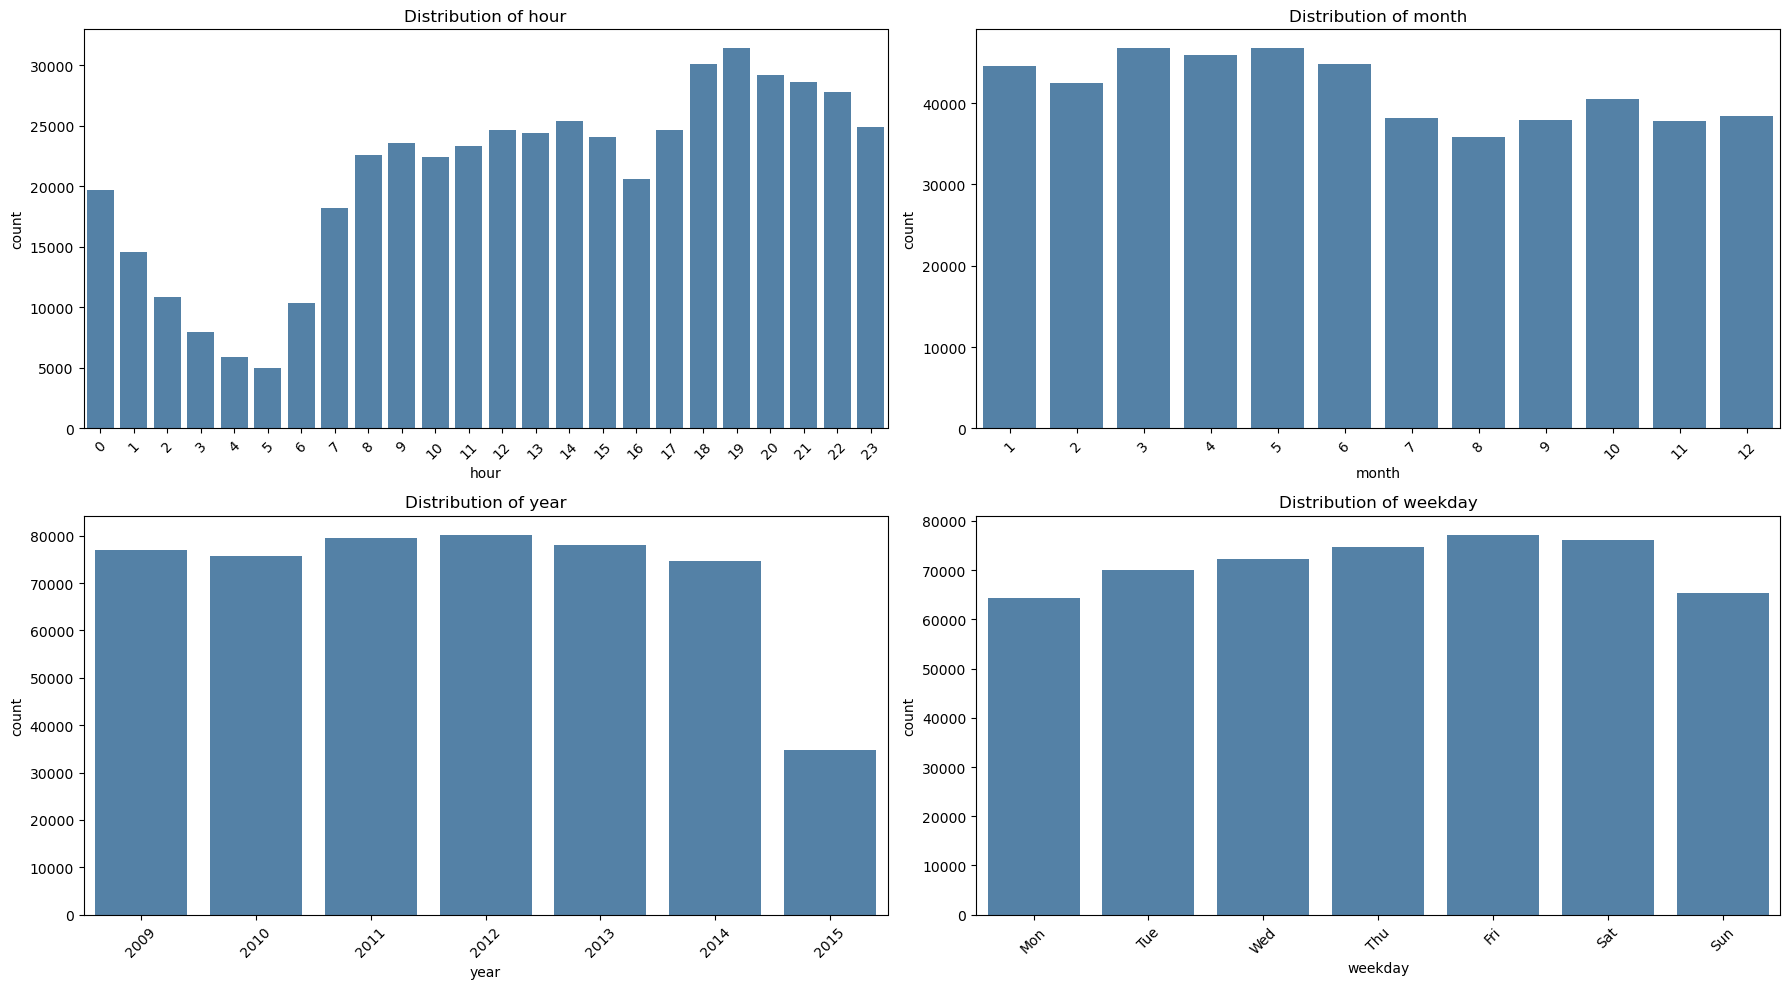

In [19]:
# distribution of day, hour, month, year, weekday in subplots
cols = ['hour', 'month', 'year', 'weekday']

weekday_map = {
    0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu',
    4: 'Fri', 5: 'Sat', 6: 'Sun'
}

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    if col == 'weekday':
        order = [0, 1, 2, 3, 4, 5, 6]
        sns.countplot(data=df, x=col, order=order, ax=axes[i], color='steelblue')
        axes[i].set_xticks(order)
        axes[i].set_xticklabels([weekday_map[d] for d in order], rotation=45)
    else:
        sns.countplot(data=df, x=col, ax=axes[i], color='steelblue')
        axes[i].tick_params(axis='x', rotation=45)

    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

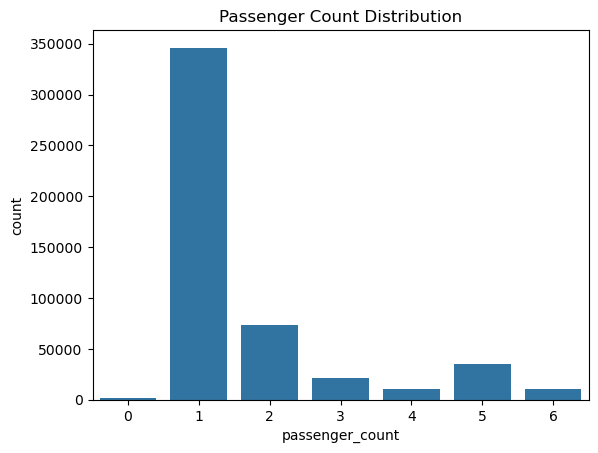

In [20]:
# Passenger count distribution
sns.countplot(data=df, x='passenger_count', order=sorted(df['passenger_count'].unique()))
plt.title('Passenger Count Distribution')
plt.show()

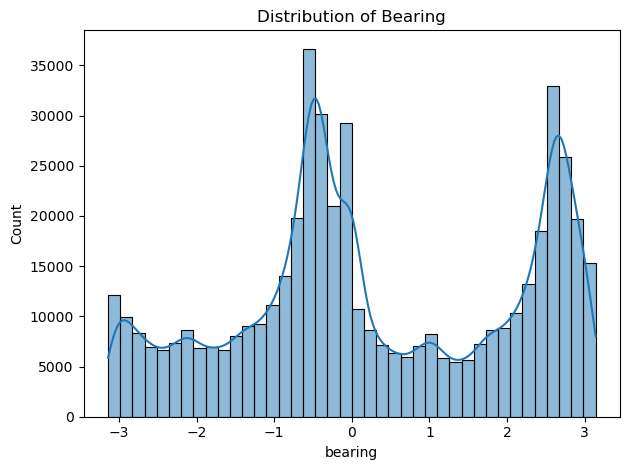

In [21]:
sns.histplot(df['bearing'], bins=40, kde=True)
plt.title('Distribution of Bearing')
plt.tight_layout()
plt.show()

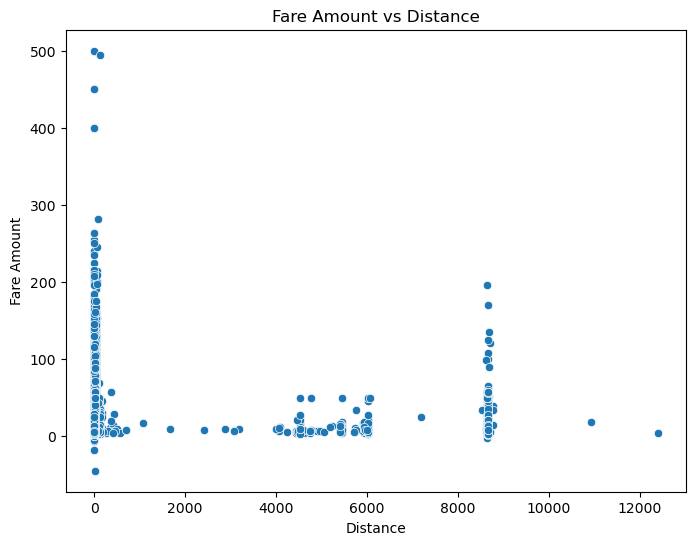

In [22]:
# 1) Scatter with regression line
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df, x='distance', y='fare_amount')
plt.title('Fare Amount vs Distance')
plt.xlabel('Distance')
plt.ylabel('Fare Amount')
plt.show()

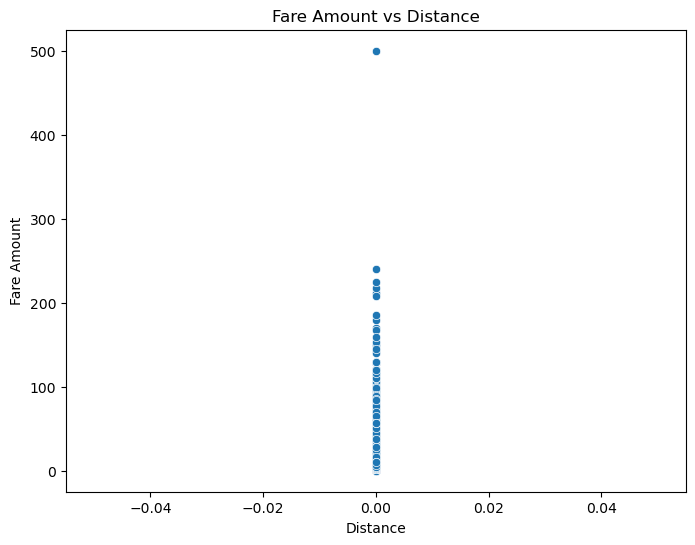

In [23]:
# Scatter plot of fare_amount vs distance == 0
plot_df = df[df['distance'] ==0]

plt.figure(figsize=(8,6))
sns.scatterplot(data=plot_df, x='distance', y='fare_amount')
plt.title('Fare Amount vs Distance')
plt.xlabel('Distance')
plt.ylabel('Fare Amount')
plt.show()

In [24]:
z = df[df['distance'] == 0]
z['fare_amount'].describe()

count    14250.000000
mean        11.539022
std         13.728286
min          0.000000
25%          5.300000
50%          7.700000
75%         12.000000
max        500.000000
Name: fare_amount, dtype: float64

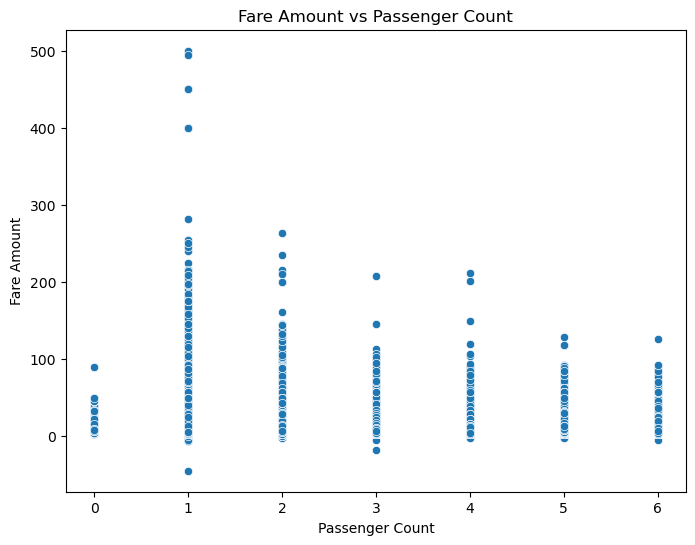

In [25]:
# Passenger count vs fare amount
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='passenger_count', y='fare_amount')
plt.title('Fare Amount vs Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount')
plt.show()

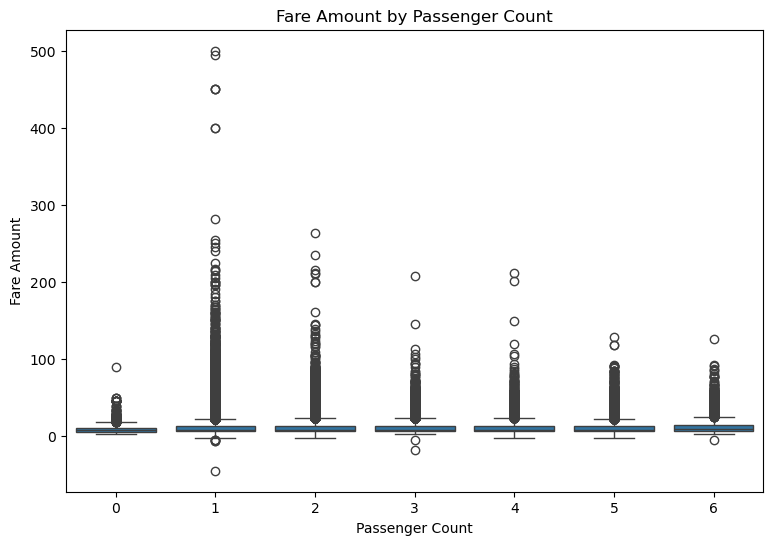

In [26]:
plt.figure(figsize=(9,6))
sns.boxplot(data=df, x='passenger_count', y='fare_amount')
plt.title('Fare Amount by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount')
plt.show()

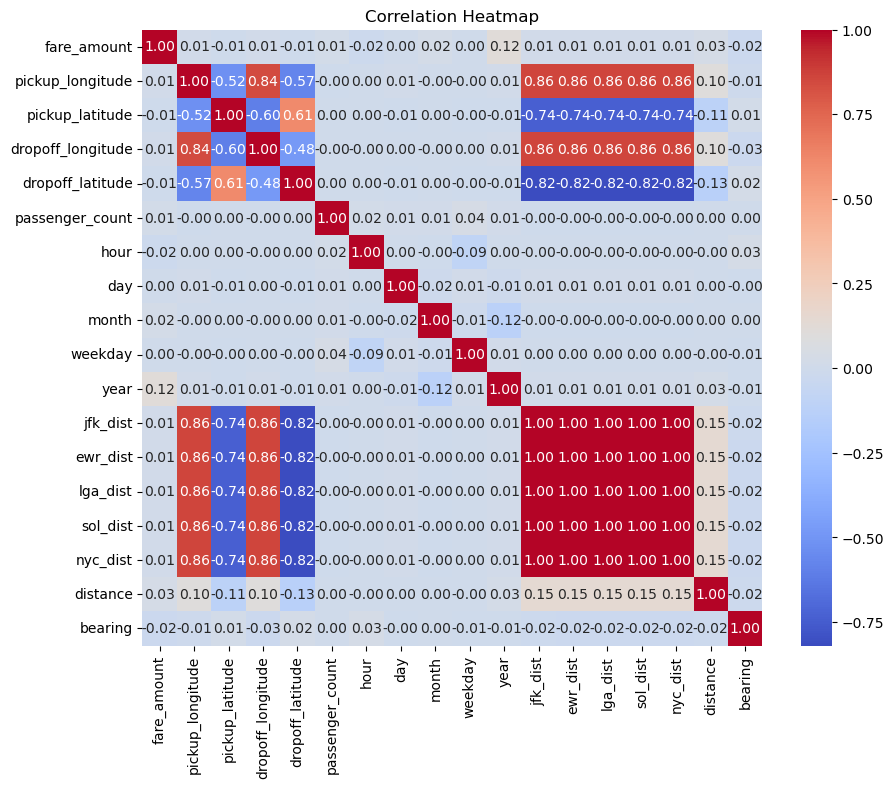

In [27]:
# --- Correlation heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

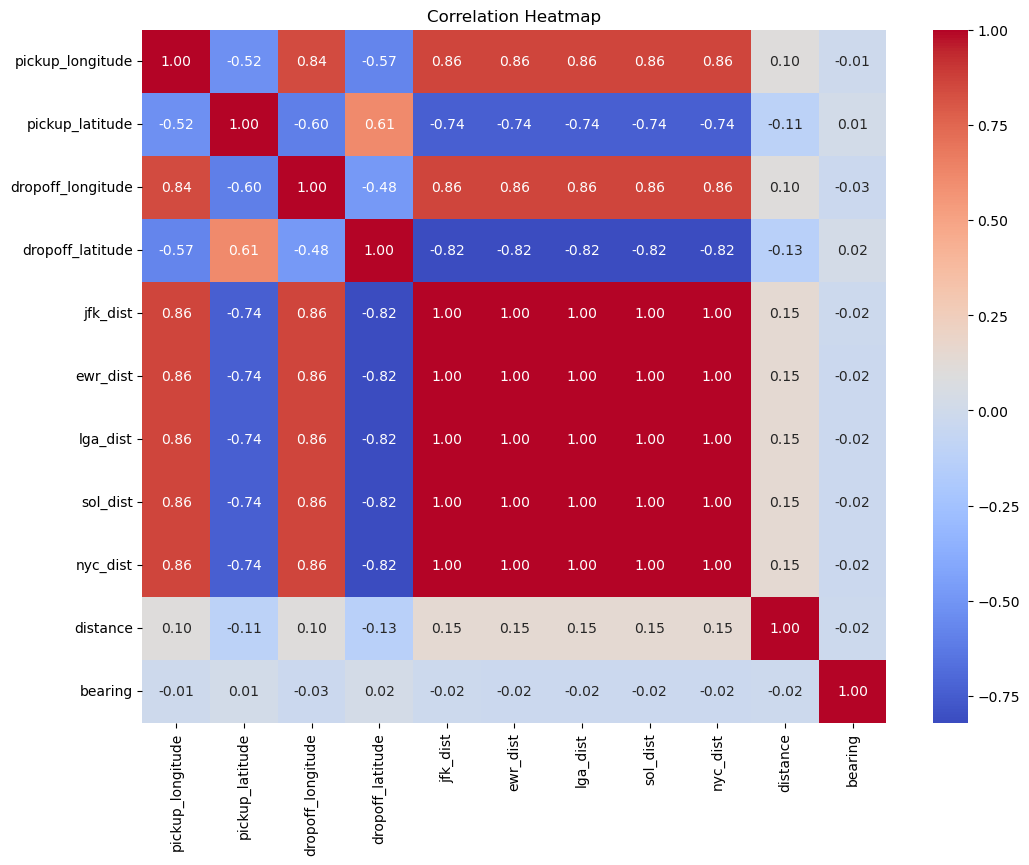

In [28]:
# Correlation heatmap for specific columns
cols = ['pickup_longitude','pickup_latitude','dropoff_longitude','dropoff_latitude', 'jfk_dist','ewr_dist','lga_dist','sol_dist','nyc_dist','distance','bearing']
plt.figure(figsize=(12,9))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

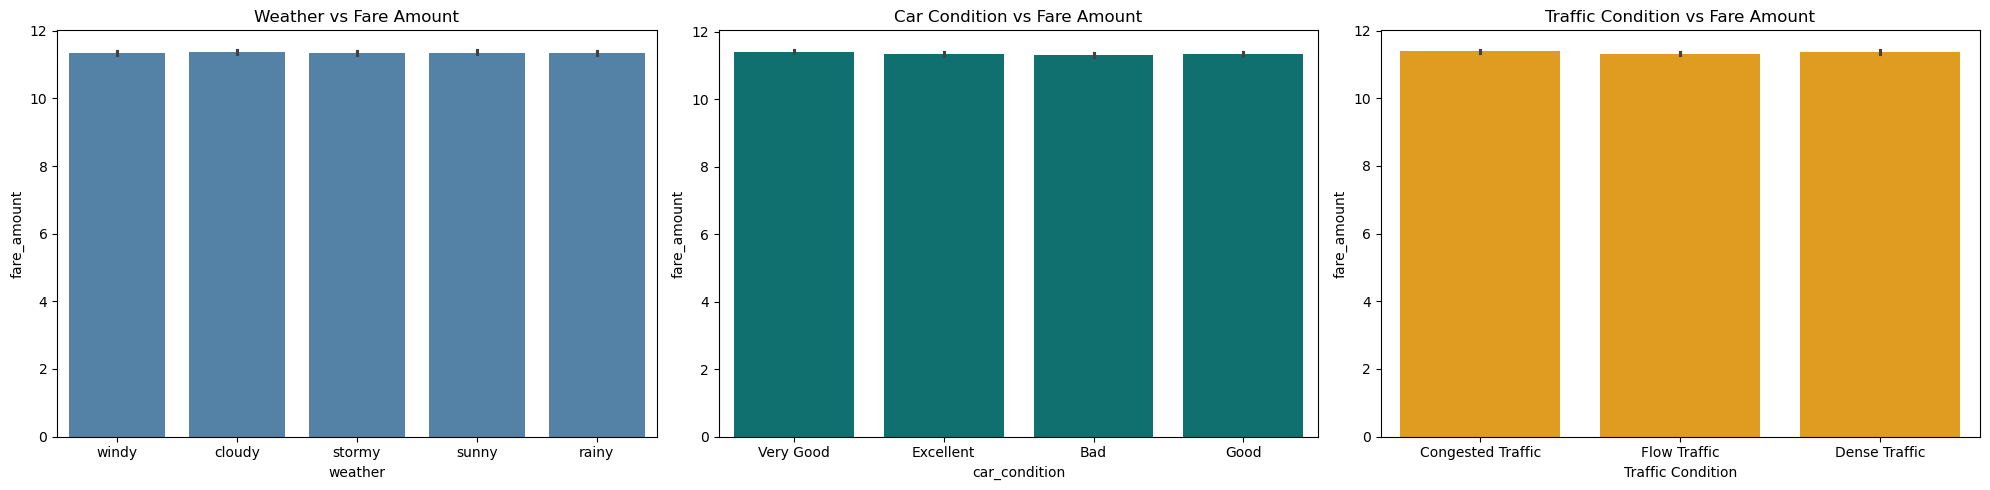

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1) 
sns.barplot(x='weather', y='fare_amount', data=df, ax=axes[0], color='steelblue')
axes[0].set_title('Weather vs Fare Amount')
axes[0].set_xlabel('weather')

# 2) 
sns.barplot(x='car_condition', y='fare_amount', data=df, ax=axes[1], color='teal')
axes[1].set_title('Car Condition vs Fare Amount')
axes[1].set_xlabel('car_condition')

# 3) 
sns.barplot(x='traffic_condition', y='fare_amount', data=df, ax=axes[2], color='orange')
axes[2].set_title('Traffic Condition vs Fare Amount')
axes[2].set_xlabel('Traffic Condition')

plt.tight_layout()
plt.show()

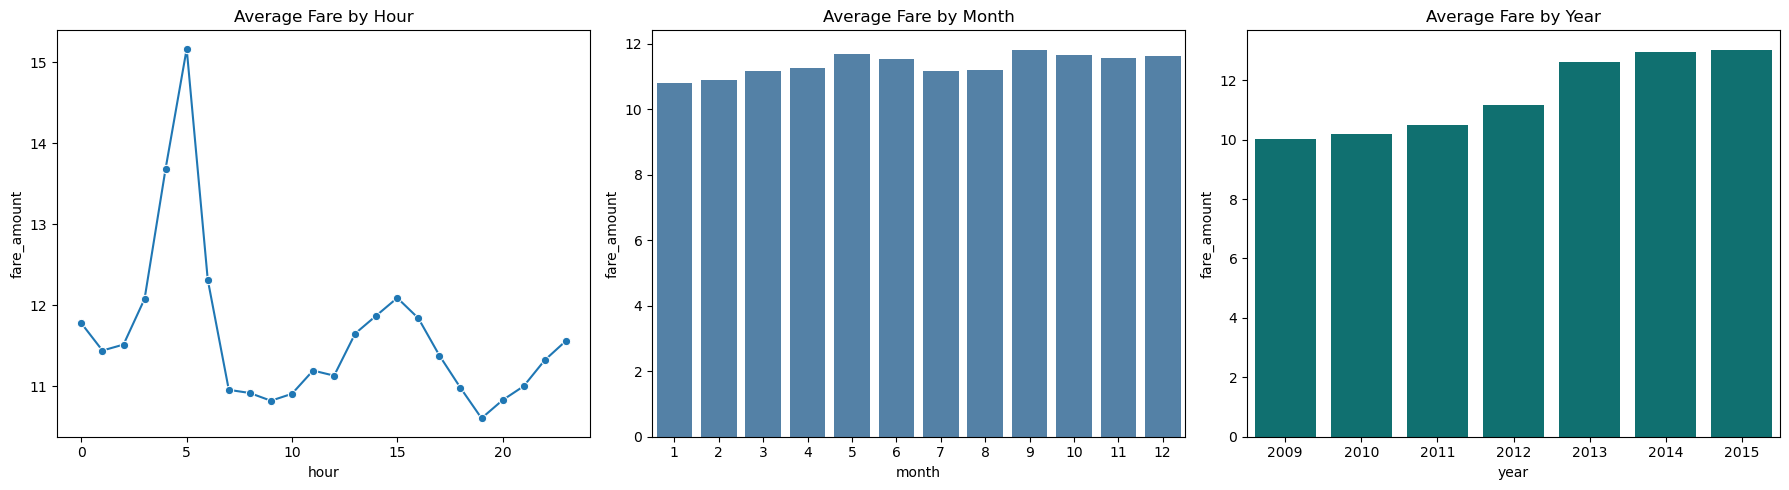

In [81]:
# average fare by hour, month, year
fare_by_hour  = df.groupby('hour', as_index=False)['fare_amount'].mean()
fare_by_month = df.groupby('month', as_index=False)['fare_amount'].mean()
fare_by_year  = df.groupby('year', as_index=False)['fare_amount'].mean()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.lineplot(data=fare_by_hour, x='hour', y='fare_amount', marker='o', ax=axes[0])
axes[0].set_title('Average Fare by Hour')

sns.barplot(data=fare_by_month, x='month', y='fare_amount', ax=axes[1], color='steelblue')
axes[1].set_title('Average Fare by Month')

sns.barplot(data=fare_by_year, x='year', y='fare_amount', ax=axes[2], color='teal')
axes[2].set_title('Average Fare by Year')

plt.tight_layout()
plt.show()

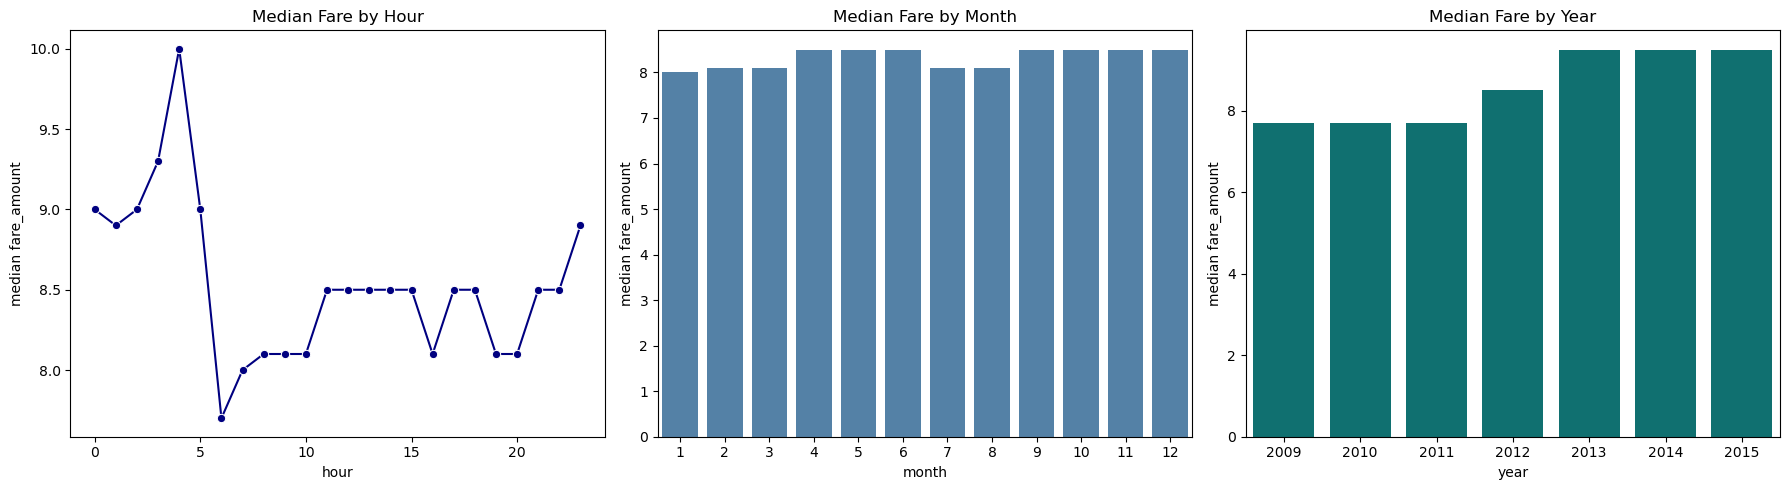

In [82]:
# Median fare by hour, month, year
fare_med_hour  = df.groupby('hour', as_index=False)['fare_amount'].median()
fare_med_month = df.groupby('month', as_index=False)['fare_amount'].median()
fare_med_year  = df.groupby('year', as_index=False)['fare_amount'].median()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.lineplot(data=fare_med_hour, x='hour', y='fare_amount', marker='o', ax=axes[0], color='navy')
axes[0].set_title('Median Fare by Hour')
axes[0].set_ylabel('median fare_amount')

sns.barplot(data=fare_med_month, x='month', y='fare_amount', ax=axes[1], color='steelblue')
axes[1].set_title('Median Fare by Month')
axes[1].set_ylabel('median fare_amount')

sns.barplot(data=fare_med_year, x='year', y='fare_amount', ax=axes[2], color='teal')
axes[2].set_title('Median Fare by Year')
axes[2].set_ylabel('median fare_amount')

plt.tight_layout()
plt.show()

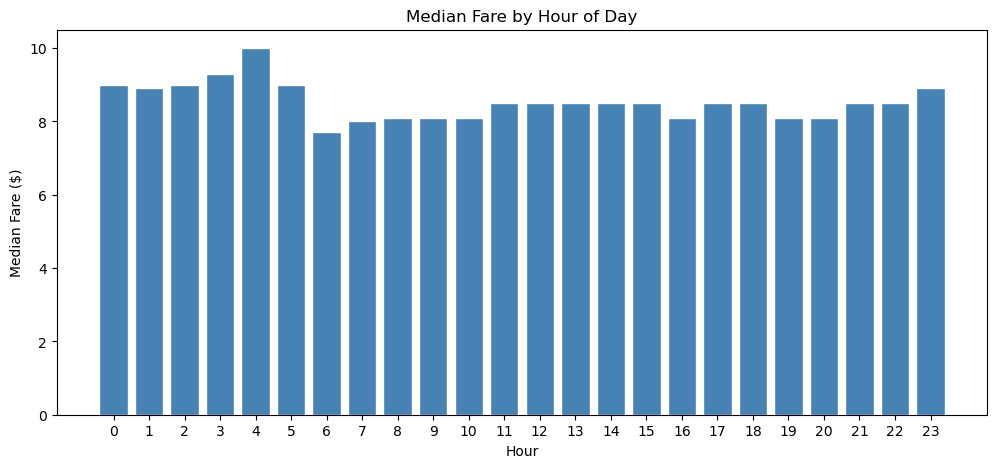

In [83]:
if "hour" in df.columns:
    fare_by_hour = df.groupby("hour")["fare_amount"].median()
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(fare_by_hour.index, fare_by_hour.values, color="steelblue", edgecolor="white")
    ax.set_title("Median Fare by Hour of Day")
    ax.set_xlabel("Hour")
    ax.set_ylabel("Median Fare ($)")
    ax.set_xticks(range(24))
    plt.show()

In [84]:
hour_stats = df.groupby('hour')['fare_amount'].agg(['count','mean','median'])
print(hour_stats)

      count       mean  median
hour                          
0     19650  11.774804     9.0
1     14556  11.438250     8.9
2     10884  11.511949     9.0
3      7936  12.076379     9.3
4      5864  13.687069    10.0
5      4982  15.166068     9.0
6     10326  12.314031     7.7
7     18231  10.952701     8.0
8     22599  10.913638     8.1
9     23565  10.817963     8.1
10    22428  10.904111     8.1
11    23338  11.191079     8.5
12    24649  11.128079     8.5
13    24404  11.648150     8.5
14    25385  11.869480     8.5
15    24025  12.088543     8.5
16    20569  11.837232     8.1
17    24646  11.376808     8.5
18    30063  10.977634     8.5
19    31382  10.601758     8.1
20    29193  10.825642     8.1
21    28639  10.997743     8.5
22    27817  11.319215     8.5
23    24864  11.555971     8.9


In [85]:
df.groupby('weekday')['fare_amount'].median(),df['weekday'].value_counts().sort_index()

(weekday
 0    8.1
 1    8.5
 2    8.5
 3    8.5
 4    8.5
 5    8.5
 6    8.5
 Name: fare_amount, dtype: float64,
 weekday
 0    64237
 1    69929
 2    72230
 3    74776
 4    77224
 5    76212
 6    65387
 Name: count, dtype: int64)

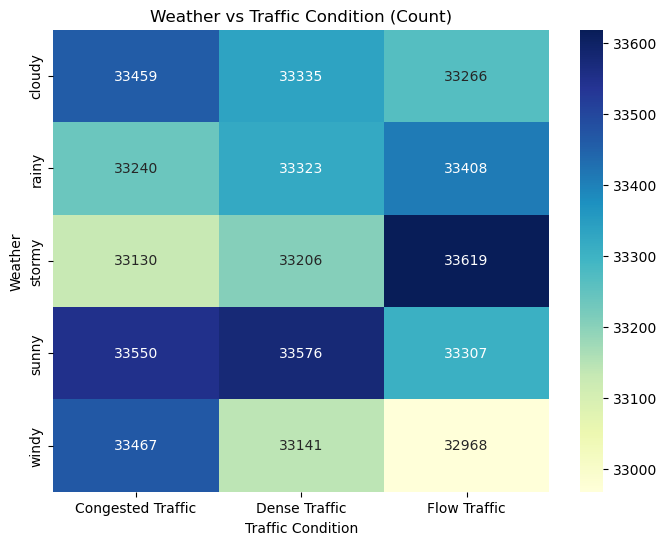

In [86]:
ct = pd.crosstab(df['weather'], df['traffic_condition'])

plt.figure(figsize=(8,6))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Weather vs Traffic Condition (Count)')
plt.xlabel('Traffic Condition')
plt.ylabel('Weather')
plt.show()

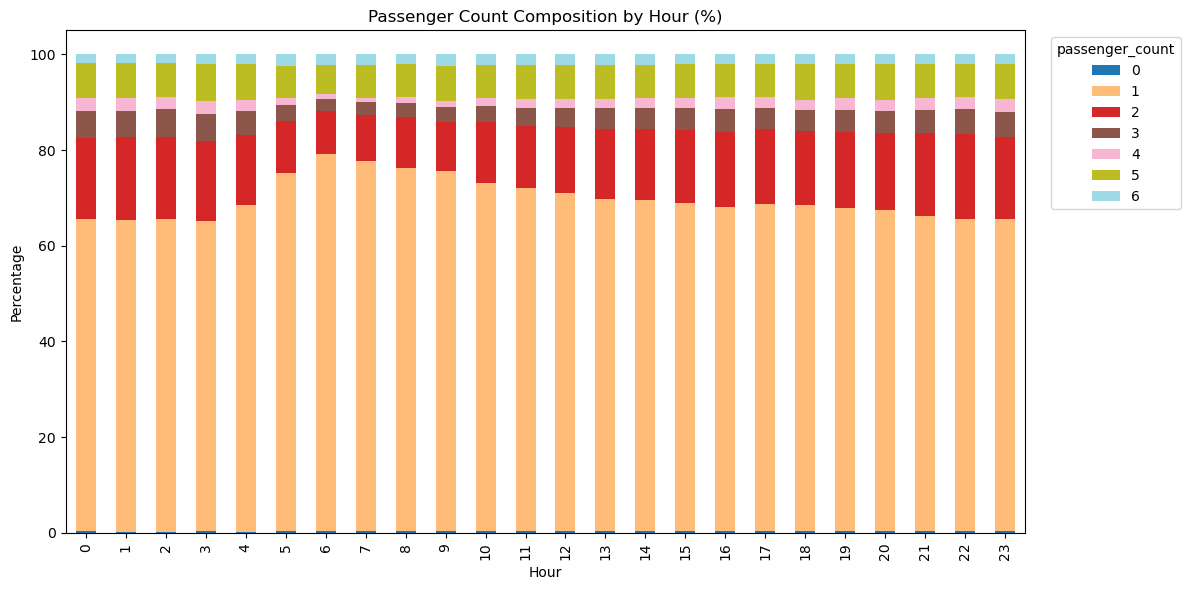

In [88]:
ct = pd.crosstab(df['hour'], df['passenger_count'], normalize='index') * 100

ct.plot(kind='bar', stacked=True, figsize=(12,6), colormap='tab20')
plt.title('Passenger Count Composition by Hour (%)')
plt.xlabel('Hour')
plt.ylabel('Percentage')
plt.legend(title='passenger_count', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()